In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("bank.csv", sep=";")


In [3]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


## Basic EDA

(4521, 17)
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


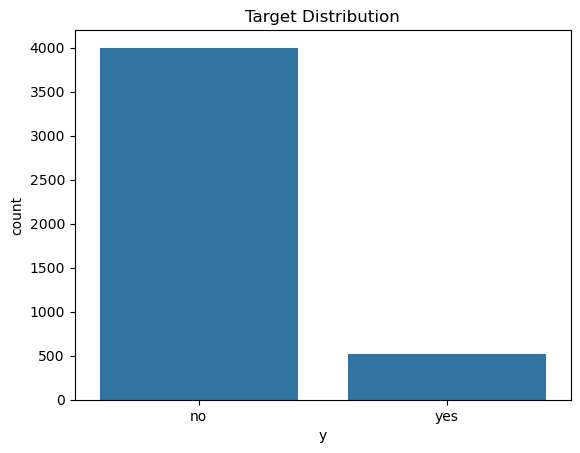

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

print(df.shape)
print(df.isnull().sum())

sns.countplot(x='y', data=df)
plt.title("Target Distribution")
plt.show()

In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

      Feature  Importance
11   duration    0.288022
0         age    0.107364
5     balance    0.106417
9         day    0.092938
10      month    0.082661
1         job    0.050665
13      pdays    0.050082
15   poutcome    0.048659
12   campaign    0.039383
3   education    0.029826


In [6]:
from sklearn.preprocessing import LabelEncoder


In [7]:
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])


In [8]:
X = df.drop("y", axis=1)
y = df["y"]


In [9]:
from sklearn.model_selection import train_test_split


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [12]:
model = RandomForestClassifier(n_estimators=200)
model.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
pred = model.predict(X_test)


In [14]:
print(confusion_matrix(y_test, pred))


[[786  21]
 [ 69  29]]


In [15]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95       807
           1       0.58      0.30      0.39        98

    accuracy                           0.90       905
   macro avg       0.75      0.63      0.67       905
weighted avg       0.88      0.90      0.89       905

